# Time-resolved discriminant analysis

In [ ]:
# PCA interpretation notebook: timewise discriminant score and separation metrics
from __future__ import annotations

import os
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, List, Any

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# -------------------------------
# Configuration
# -------------------------------
PROJECT_ROOT = Path("/Users/johnmadrid/GitHub/pca-driving-behavior").resolve()
# DATA_CSV = PROJECT_ROOT / "results/cleaned_new/event_one/cleaned_event_one_timestamp_all_7_variables.csv"
DATA_CSV = PROJECT_ROOT / "results/cleaned_new/all_events/cleaned_event_all_events_timestamp_all_7_variables.csv"
OUTPUT_DIR = PROJECT_ROOT / "results/pc-interp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Variables to use (column names in the cleaned CSV)
FEATURES = [
    "Eye Horizontal",
    "Eye Vertical",
    "Car Yaw",
    "Head Yaw",
    "Head Pitch",
    "Head Roll",
    "Steering",
]

TIME_COL = "Time"
COND_COL = "Condition"  # 0/1 numeric codes in the cleaned CSV
EVENT_COL = "Event"
UID_COL = "uid"  # participant identifier

# Optional: mark hazard onset (seconds); set to None if unknown
HAZARD_ONSET: float | None = None  # e.g., 22.5

# Bootstrap and CV settings
BOOTSTRAP_REPS = 200
CV_FOLDS = 5
RANDOM_STATE = 42

# Permutation test settings
PERM_REPS = 200  # increase (e.g., 1000) for publication; 200 for speed
FDR_ALPHA = 0.05

# Practical AUC threshold for strong separation
PRACTICAL_AUC_THRESH = 0.80

np.random.seed(RANDOM_STATE)

# Plot style
mpl.rcParams.update({
    "figure.figsize": (11, 6.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
})

print(f"Reading: {DATA_CSV}")
df = pd.read_csv(DATA_CSV)
# Keep only needed columns to reduce memory
required_cols = FEATURES + [COND_COL, TIME_COL, EVENT_COL, UID_COL]
df = df[required_cols].copy()

# Map numeric condition to labels for plotting
COND_MAP = {0: "Autonomous", 1: "Manual"}
df["ConditionName"] = df[COND_COL].map(COND_MAP)

# Sort by time for stable iteration
unique_times = np.sort(df[TIME_COL].unique())
print(f"Found {len(unique_times)} unique timestamps; rows: {len(df):,}")

Reading: /Users/johnmadrid/GitHub/pca-driving-behavior/results/cleaned_new/all_events/cleaned_event_all_events_timestamp_all_7_variables.csv
Found 23717 unique timestamps; rows: 6,734,184


In [2]:
# Debug/verbosity controls
DEBUG = True  # set False to silence prints
# Choose which times to print detailed diagnostics for. By default: first timestamp only.
DEBUG_TIMES = []  # e.g., [20.84, 23.78]
MAX_DEBUG_PRINTS = 2

## Helper functions

In [3]:
# Subject-level permutation p-values (UID-wise)

def _perm_p_values_uid(time_cache: Dict[float, Dict[str, Any]],
                        perm_reps: int = PERM_REPS,
                        random_state: int = RANDOM_STATE) -> Dict[str, Dict[float, float]]:
    """
    Compute permutation p-values for AUC and centroid distance using subject-level (UID-wise) permutations.
    - time_cache: mapping Time -> { 'scores': ndarray[n_samples_t, 2], 'uids': ndarray[n_samples_t],
                                    'y': ndarray[n_samples_t], 'auc_obs': float, 'dist_obs': float }
    Returns dict with two sub-dicts: {'p_auc': {t: p}, 'p_dist': {t: p}}.
    """
    rng = np.random.default_rng(random_state)

    # Build uid->label from any timepoint (assume constant per uid). Use mode if needed.
    # Gather all uids and labels
    all_uid_list = []
    all_label_list = []
    for t, obj in time_cache.items():
        all_uid_list.extend(list(obj['uids']))
        all_label_list.extend(list(obj['y']))
    all_uid = np.asarray(all_uid_list)
    all_label = np.asarray(all_label_list)
    # Unique uids and modal label per uid
    uniq_uids, inv = np.unique(all_uid, return_inverse=True)
    # For each uid, take modal label
    uid_label = np.zeros(len(uniq_uids), dtype=int)
    for i, u in enumerate(uniq_uids):
        labs = all_label[all_uid == u]
        if labs.size == 0:
            uid_label[i] = 0
        else:
            # mode
            vals, counts = np.unique(labs, return_counts=True)
            uid_label[i] = int(vals[np.argmax(counts)])

    # Observed values per time
    auc_obs = {t: time_cache[t]['auc_obs'] for t in time_cache}
    dist_obs = {t: time_cache[t]['dist_obs'] for t in time_cache}

    # Counters for exceedances
    count_auc = {t: 0 for t in time_cache}
    count_dist = {t: 0 for t in time_cache}

    # Permutation loop
    for _ in range(perm_reps):
        perm_indices = rng.permutation(len(uniq_uids))
        perm_uid_label = uid_label[perm_indices]
        # Map uid -> perm label via index lookup
        uid_to_perm = {u: int(lbl) for u, lbl in zip(uniq_uids, perm_uid_label)}
        # For each time, construct y_perm and compute stats
        for t, obj in time_cache.items():
            uids_t = obj['uids']
            scores_t = obj['scores']
            y_perm_t = np.array([uid_to_perm[u] for u in uids_t], dtype=int)
            auc_p = _cv_auc(scores_t, y_perm_t, CV_FOLDS)
            _, _, _, _, _, dist_p = _compute_discriminant(scores_t, y_perm_t, prev_v=None)
            if auc_p >= auc_obs[t]:
                count_auc[t] += 1
            if dist_p >= dist_obs[t]:
                count_dist[t] += 1

    p_auc = {t: float((1 + count_auc[t]) / (1 + perm_reps)) for t in time_cache}
    p_dist = {t: float((1 + count_dist[t]) / (1 + perm_reps)) for t in time_cache}

    return { 'p_auc': p_auc, 'p_dist': p_dist }

In [4]:
# Compute PCA
def _compute_pca_scores(X: np.ndarray, n_components: int = 2) -> Tuple[np.ndarray, PCA, StandardScaler]:
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=n_components, svd_solver="full", whiten=False, random_state=RANDOM_STATE)
    scores = pca.fit_transform(Xs)
    return scores, pca, scaler


def _compute_discriminant(scores: np.ndarray, y: np.ndarray, prev_v: np.ndarray | None) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, float, float]:
    # centroids in score space
    c0 = scores[y == 0].mean(axis=0)
    c1 = scores[y == 1].mean(axis=0)
    v = c0 - c1
    norm = np.linalg.norm(v)
    if norm == 0 or np.isnan(norm):
        v = np.array([1.0, 0.0])
        norm = 1.0
    else:
        v = v / norm

    # Ensure temporal orientation continuity
    if prev_v is not None and np.dot(v, prev_v) < 0:
        v = -v

    m = 0.5 * (c0 + c1)
    # project to scalar
    s = (scores - m) @ v
    s0 = np.nanmean(s[y == 0])
    s1 = np.nanmean(s[y == 1])
    dist = float(np.linalg.norm(c0 - c1))
    return v, m, s, float(s0), float(s1), dist


def _cv_auc(scores: np.ndarray, y: np.ndarray, n_splits: int = CV_FOLDS) -> float:
    # Robust choice of folds
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, n_splits))
    if max_folds < 2:
        # Fallback: in-sample AUC (optimistic)
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        prob = clf.predict_proba(scores)[:, 1]
        return float(roc_auc_score(y, prob))
    skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
    prob_all = np.zeros(len(y))
    for train, test in skf.split(scores, y):
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores[train], y[train])
        prob_all[test] = clf.predict_proba(scores[test])[:, 1]
    return float(roc_auc_score(y, prob_all))


def _oof_probabilities(scores: np.ndarray, y: np.ndarray, n_splits: int = CV_FOLDS) -> np.ndarray:
    """Return out-of-fold probabilities for class 1. Falls back to in-sample if folds<2."""
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, n_splits))
    if max_folds < 2:
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        return clf.predict_proba(scores)[:, 1]
    skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
    prob_all = np.zeros(len(y))
    for train, test in skf.split(scores, y):
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores[train], y[train])
        prob_all[test] = clf.predict_proba(scores[test])[:, 1]
    return prob_all


def _bootstrap_ci_scores(scores: np.ndarray, y: np.ndarray, reps: int = BOOTSTRAP_REPS,
                          random_state: int = RANDOM_STATE,
                          prev_v: np.ndarray | None = None) -> Dict[str, Tuple[float, float]]:
    rng = np.random.default_rng(random_state)
    s0_vals, s1_vals, dist_vals = [], [], []
    v = prev_v
    for _ in range(reps):
        # resample within each class
        idx0 = np.where(y == 0)[0]
        idx1 = np.where(y == 1)[0]
        if len(idx0) == 0 or len(idx1) == 0:
            break
        b0 = rng.choice(idx0, size=len(idx0), replace=True)
        b1 = rng.choice(idx1, size=len(idx1), replace=True)
        bidx = np.concatenate([b0, b1])
        b_scores = scores[bidx]
        b_y = y[bidx]
        v, m, s, s0, s1, dist = _compute_discriminant(b_scores, b_y, v)
        s0_vals.append(s0)
        s1_vals.append(s1)
        dist_vals.append(dist)
    def ci(x):
        if len(x) == 0:
            return (np.nan, np.nan)
        lo, hi = np.percentile(x, [2.5, 97.5])
        return (float(lo), float(hi))
    return {
        "s0": ci(s0_vals),
        "s1": ci(s1_vals),
        "dist": ci(dist_vals),
    }


def _perm_p_values(scores: np.ndarray, y: np.ndarray, perm_reps: int = PERM_REPS) -> Tuple[float, float]:
    """
    Return (p_auc, p_dist) by permuting labels and recomputing AUC and centroid distance.
    Uses the same scores (aligned PC plane). AUC uses in-sample logistic if folds<2.
    """
    # Observed
    auc_obs = _cv_auc(scores, y, CV_FOLDS)
    _, _, _, _, _, dist_obs = _compute_discriminant(scores, y, prev_v=None)

    rng = np.random.default_rng(RANDOM_STATE)
    auc_perm = []
    dist_perm = []
    for _ in range(perm_reps):
        y_perm = rng.permutation(y)
        auc_p = _cv_auc(scores, y_perm, CV_FOLDS)
        _, _, _, _, _, dist_p = _compute_discriminant(scores, y_perm, prev_v=None)
        auc_perm.append(auc_p)
        dist_perm.append(dist_p)

    auc_perm = np.asarray(auc_perm)
    dist_perm = np.asarray(dist_perm)
    p_auc = float((1 + np.sum(auc_perm >= auc_obs)) / (1 + perm_reps))
    p_dist = float((1 + np.sum(dist_perm >= dist_obs)) / (1 + perm_reps))
    return p_auc, p_dist


def _pr_from_probs(y: np.ndarray, prob: np.ndarray) -> Dict[str, float]:
    """Compute per-time PR metrics from OOF probabilities."""
    from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
    precision, recall, thresholds = precision_recall_curve(y, prob)
    ap = float(average_precision_score(y, prob))
    # Fixed threshold @ 0.5
    yhat_05 = (prob >= 0.5).astype(int)
    from sklearn.metrics import precision_score, recall_score
    p05 = float(precision_score(y, yhat_05, zero_division=0))
    r05 = float(recall_score(y, yhat_05, zero_division=0))
    try:
        f105 = float(f1_score(y, yhat_05))
    except Exception:
        f105 = float(0.0)
    # Max F1 over thresholds
    f1s = 2 * (precision * recall) / np.maximum(precision + recall, 1e-12)
    idx = int(np.nanargmax(f1s))
    f1max = float(f1s[idx])
    # thresholds array has length-1 of precision/recall; clamp index
    if idx >= len(thresholds):
        idx_thr = len(thresholds) - 1
    else:
        idx_thr = idx
    thr_star = float(thresholds[max(0, idx_thr)]) if thresholds.size > 0 else float(0.5)
    p_star = float(precision[min(idx, len(precision) - 1)])
    r_star = float(recall[min(idx, len(recall) - 1)])
    prevalence = float(np.mean(y))
    # TPR@0.5 and FPR@0.5
    tp = float(np.sum((y == 1) & (yhat_05 == 1)))
    fn = float(np.sum((y == 1) & (yhat_05 == 0)))
    tn = float(np.sum((y == 0) & (yhat_05 == 0)))
    fp = float(np.sum((y == 0) & (yhat_05 == 1)))
    tpr05 = tp / max(tp + fn, 1.0)
    fpr05 = fp / max(fp + tn, 1.0)
    youden = tpr05 - fpr05
    return {
        "AP": ap,
        "precision_0p5": p05,
        "recall_0p5": r05,
        "f1_0p5": f105,
        "f1_max": f1max,
        "thresh_f1_max": thr_star,
        "precision_f1_max": p_star,
        "recall_f1_max": r_star,
        "prevalence": prevalence,
        "tpr_0p5": tpr05,
        "fpr_0p5": fpr05,
        "youden_j": youden,
    }



In [5]:
# Alignment helpers: sign flips + optional orthogonal Procrustes
import numpy.linalg as npl

def _orthogonal_procrustes(A: np.ndarray, B: np.ndarray, allow_reflection: bool = False) -> np.ndarray:
    """
    Return R (2x2) minimizing ||A R - B||_F with R orthogonal.
    A and B are [n_features x 2] loading matrices.
    """
    S = A.T @ B  # 2x2
    U, _, Vt = npl.svd(S)
    R = U @ Vt
    if not allow_reflection and np.linalg.det(R) < 0:
        U[:, -1] *= -1.0
        R = U @ Vt
    return R


def _align_basis(loadings: np.ndarray, ref_loadings: np.ndarray | None,
                  prev_loadings: np.ndarray | None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Align current [n_features x 2] loadings to reference basis.
    Returns (aligned_loadings, R). Applies Procrustes rotation; then enforces
    column-wise sign continuity vs prev_loadings if provided.
    """
    if ref_loadings is None:
        R = np.eye(2)
        aligned = loadings.copy()
    else:
        R = _orthogonal_procrustes(loadings, ref_loadings, allow_reflection=False)
        aligned = loadings @ R
    # Enforce continuity of each component sign using prev_loadings if available
    if prev_loadings is not None:
        for j in range(aligned.shape[1]):
            if np.dot(aligned[:, j], prev_loadings[:, j]) < 0:
                aligned[:, j] *= -1.0
                R[:, j] *= -1.0
    return aligned, R



## Plotting functions

In [6]:
# Model performance plot: AP and precision/recall/F1 over time
def plot_model_performance(metrics_df: pd.DataFrame, out_suffix: str = "aligned") -> None:
    times = metrics_df["Time"].to_numpy()
    fig, axes = plt.subplots(4, 1, figsize=(10,8), sharex=True)

    # Panel 1: Average Precision (AP) and prevalence reference
    ax = axes[0]
    ax.plot(times, metrics_df["AP"], color="#1b9e77", label="AP")
    ax.axhline(metrics_df["prevalence"].mean(), color="gray", ls=":", lw=1, alpha=0.7, label="Prevalence")
    ax.set_ylabel("Average Precision")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 2: Precision/Recall at threshold 0.5
    ax = axes[1]
    ax.plot(times, metrics_df["precision_0p5"], color="#7570b3", label="Precision@0.5")
    ax.plot(times, metrics_df["recall_0p5"], color="#d95f02", label="Recall@0.5")
    ax.set_ylabel("P/R @0.5")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 3: Max F1 and its threshold (as a secondary axis marker if desired)
    ax = axes[2]
    ax.plot(times, metrics_df["f1_max"], color="#e7298a", label="Max F1")
    ax.set_ylabel("Max F1")
    ax.set_xlim(times.min(), times.max())
    ax.set_ylim(0.0, 1.0)
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 4: TPR/FPR/Youden at threshold 0.5
    ax = axes[3]
    ax.plot(times, metrics_df["tpr_0p5"], color="#1f78b4", label="TPR@0.5")
    ax.plot(times, metrics_df["fpr_0p5"], color="#e31a1c", label="FPR@0.5")
    ax.plot(times, metrics_df["youden_j"], color="#33a02c", ls="--", label="Youden's J")
    ax.axhline(0.0, color="gray", ls=":", lw=1, alpha=0.7)
    ax.set_ylabel("TPR/FPR/Youden @0.5")
    ax.set_xlabel("Time (s)")
    ax.set_xlim(times.min(), times.max())
    ax.set_ylim(0.0, 1.0)
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    fig.tight_layout()
    out_path = OUTPUT_DIR / f"model_performance_{out_suffix}.png"
    fig.savefig(out_path, dpi=200)
    print("Saved:", out_path)


In [16]:
# Consolidated: compute metrics and plot panels (aligned or not)
from typing import Dict

def compute_timewise_pca_metrics(df_in: pd.DataFrame,
                                 feature_cols: List[str],
                                 align: bool = True,
                                 out_suffix: str = "aligned",
                                 permute_by: str = "uid",
                                 save_csv: bool = True) -> pd.DataFrame:
    """Compute observed metrics and attach permutation p-values.
    permute_by: 'uid' (subject-level, recommended) or 'row' (legacy per-timepoint shuffle).
    save_csv: if True, save per-call CSV; set False when aggregating across events.
    """
    ref_loadings: np.ndarray | None = None
    prev_loadings: np.ndarray | None = None
    prev_v: np.ndarray | None = None
    records: List[Dict[str, float]] = []

    # Cache per time for UID-wise permutations
    time_cache: Dict[float, Dict[str, Any]] = {}

    for t in np.sort(df_in[TIME_COL].unique()):
        dft = df_in[df_in[TIME_COL] == t]
        X = dft[feature_cols].to_numpy(dtype=float)
        y = dft[COND_COL].to_numpy(dtype=int)
        uids = dft[UID_COL].to_numpy()
        if X.shape[0] < 3:
            continue

        scores_raw, pca, scaler = _compute_pca_scores(X, n_components=2)
        if align:
            loadings = pca.components_.T
            aligned_loadings, R = _align_basis(loadings, ref_loadings, prev_loadings)
            scores = scores_raw @ R
            if ref_loadings is None:
                ref_loadings = aligned_loadings.copy()
            prev_loadings = aligned_loadings.copy()
        else:
            scores = scores_raw

        v, m, s, s0, s1, dist = _compute_discriminant(scores, y, prev_v)
        prev_v = v
        cis = _bootstrap_ci_scores(scores, y, BOOTSTRAP_REPS, RANDOM_STATE, prev_v)
        auc = _cv_auc(scores, y, CV_FOLDS)

        # Permutation p-values
        if permute_by == "row":
            p_auc, p_dist = _perm_p_values(scores, y, PERM_REPS)
        else:
            p_auc, p_dist = (np.nan, np.nan)  # filled later via UID-wise permutations

        # OOF probabilities and PR metrics
        prob_oof = _oof_probabilities(scores, y, CV_FOLDS)
        pr_metrics = _pr_from_probs(y, prob_oof)

        records.append({
            "Time": float(t),
            "Manual_score_mean": s0,
            "Autonomous_score_mean": s1,
            "Manual_score_lo": cis["s0"][0],
            "Manual_score_hi": cis["s0"][1],
            "Autonomous_score_lo": cis["s1"][0],
            "Autonomous_score_hi": cis["s1"][1],
            "CentroidDistance": dist,
            "CentroidDistance_lo": cis["dist"][0],
            "CentroidDistance_hi": cis["dist"][1],
            "AUC": auc,
            "p_auc": p_auc,
            "p_dist": p_dist,
            "auc_ge_thresh": bool(auc >= PRACTICAL_AUC_THRESH),
            # PR metrics
            "AP": pr_metrics["AP"],
            "precision_0p5": pr_metrics["precision_0p5"],
            "recall_0p5": pr_metrics["recall_0p5"],
            "f1_0p5": pr_metrics["f1_0p5"],
            "f1_max": pr_metrics["f1_max"],
            "thresh_f1_max": pr_metrics["thresh_f1_max"],
            "precision_f1_max": pr_metrics["precision_f1_max"],
            "recall_f1_max": pr_metrics["recall_f1_max"],
            "prevalence": pr_metrics["prevalence"],
            "tpr_0p5": pr_metrics["tpr_0p5"],
            "fpr_0p5": pr_metrics["fpr_0p5"],
            "youden_j": pr_metrics["youden_j"],
        })

        # Cache needed data for UID-wise permutations
        time_cache[float(t)] = {
            'scores': scores,
            'uids': uids,
            'y': y,
            'auc_obs': auc,
            'dist_obs': dist,
        }

    out_df = pd.DataFrame(records).sort_values("Time")

    # After the observed pass, run UID-wise permutations if requested
    if permute_by == "uid" and len(time_cache) > 0:
        pvals = _perm_p_values_uid(time_cache, perm_reps=PERM_REPS, random_state=RANDOM_STATE)
        out_df['p_auc'] = out_df['Time'].map(pvals['p_auc'])
        out_df['p_dist'] = out_df['Time'].map(pvals['p_dist'])

    # FDR correction (per metric across time) if p-values exist
    def fdr_bh(pvals: np.ndarray) -> np.ndarray:
        p = np.asarray(pvals, dtype=float)
        n = p.size
        order = np.argsort(p)
        ranked = p[order]
        q = ranked * n / (np.arange(n) + 1)
        q = np.minimum.accumulate(q[::-1])[::-1]
        q_corrected = np.empty_like(q)
        q_corrected[order] = q
        return q_corrected

    if out_df['p_auc'].notna().any():
        out_df["q_auc"] = fdr_bh(out_df["p_auc"].to_numpy())
    if out_df['p_dist'].notna().any():
        out_df["q_dist"] = fdr_bh(out_df["p_dist"].to_numpy())

    if save_csv:
        out_df.to_csv(OUTPUT_DIR / f"timewise_discriminant_metrics_{out_suffix}.csv", index=False)
    return out_df


def plot_timewise_panels(metrics_df: pd.DataFrame,
                          out_suffix: str = "aligned",
                          save = True,
                          ylabel_prefix: str = "aligned") -> None:
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    times = metrics_df["Time"].to_numpy()

    # Panel 1: discriminant scores (no significance here)
    ax = axes[0]
    ax.plot(times, metrics_df["Manual_score_mean"], color="#71898E", label="Manual", lw=2)
    ax.fill_between(times, metrics_df["Manual_score_lo"], metrics_df["Manual_score_hi"], color="#71898E", alpha=0.15)
    ax.plot(times, metrics_df["Autonomous_score_mean"], color="#cc2936", label="Autonomous", lw=2, ls="--")
    ax.fill_between(times, metrics_df["Autonomous_score_lo"], metrics_df["Autonomous_score_hi"], color="#cc2936", alpha=0.15)
    ax.axhline(0, color="gray", lw=1, ls="-", alpha=0.8)
    ax.set_ylabel(f"Discriminant score")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 2: centroid distance + significance strip (q_dist)
    ax = axes[1]
    ax.plot(times, metrics_df["CentroidDistance"], color="#222")
    ax.fill_between(times, metrics_df["CentroidDistance_lo"], metrics_df["CentroidDistance_hi"], color="#222", alpha=0.15)
    ax.set_ylabel(f"Centroid distance")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    if "q_dist" in metrics_df.columns:
        sig = (metrics_df["q_dist"].to_numpy() < FDR_ALPHA)
        # draw a thin strip near y=0 where significant
        ymin, ymax = ax.get_ylim()
        band_low = ymin + 0.02 * (ymax - ymin)
        band_high = ymin + 0.06 * (ymax - ymin)
        ax.fill_between(times, band_low, band_high, where=sig, color="#7e57c2", alpha=0.25, transform=ax.get_xaxis_transform(), step=None)
        patch = mpatches.Patch(color="#7e57c2", alpha=0.25, label=f"FDR<0.05 \n(distance)")
        ax.legend(handles=[patch], loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 3: AUC + significance strip (q_auc)
    ax = axes[2]
    ax.plot(times, metrics_df["AUC"], color="#444")
    ax.set_ylabel(f"AUC (PC1–PC2)")
    ax.set_xlabel("Time (s)")
    ax.set_ylim(0.0, 1.0)
    # reference lines: chance and practical threshold
    chance_line = ax.axhline(0.5, color="k", lw=1, ls=":", alpha=0.6, label="Chance")
    thresh_line = ax.axhline(PRACTICAL_AUC_THRESH, color="red", lw=1, ls="--", alpha=0.8, label=f"AUC ≥ {PRACTICAL_AUC_THRESH}")
    if "q_auc" in metrics_df.columns:
        sig = (metrics_df["q_auc"].to_numpy() < FDR_ALPHA)
        ymin, ymax = ax.get_ylim()
        band_low = ymin + 0.02 * (ymax - ymin)
        band_high = ymin + 0.06 * (ymax - ymin)
        auc_patch = mpatches.Patch(color="#2e7d32", alpha=0.25, label="FDR<0.05 (AUC)")
        # thresh_patch = mpatches.Patch(color="red", alpha=0.3, label=f"AUC ≥ {PRACTICAL_AUC_THRESH}")
        ax.fill_between(times, band_low, band_high, where=sig, color="#2e7d32", alpha=0.25, transform=ax.get_xaxis_transform(), step=None)
        # Also overlay a light strip where AUC ≥ threshold (optional, separate from FDR)
        # ge = (metrics_df["AUC"].to_numpy() >= PRACTICAL_AUC_THRESH)
        # band_low2 = ymin + 0.08 * (ymax - ymin)
        # band_high2 = ymin + 0.12 * (ymax - ymin)
        # ax.fill_between(times, band_low2, band_high2, where=ge, color="red", alpha=0.25, transform=ax.get_xaxis_transform(), step=None)
        # Add reference lines to legend
        ax.legend(
            handles=[
                auc_patch,
                # thresh_patch,
                chance_line,
                thresh_line
            ],
            loc="upper left",
            bbox_to_anchor=(1, 1),
            fontsize=9,
            frameon=True
        )
        ax.grid(False)

    if HAZARD_ONSET is not None:
        for ax in axes:
            ax.axvline(HAZARD_ONSET, color="orangered", lw=1.2, ls="--")
            ax.text(HAZARD_ONSET, ax.get_ylim()[1], " Hazard onset", color="orangered", va="top")

    fig.tight_layout()
    if save:
        out_path = OUTPUT_DIR / f"timewise_discriminant_panels_{out_suffix}.pdf"
        fig.savefig(out_path, dpi=600)
        print("Saved:", out_path)
    plt.show()

# If you want the unaligned baseline for comparison, uncomment:
# unaligned_df = compute_timewise_pca_metrics(df, FEATURES, align=False, out_suffix="unaligned")
# plot_timewise_panels(unaligned_df, out_suffix="unaligned", ylabel_prefix="unaligned")


In [8]:
# Utilities to compute metrics for all events and include 'Event' column

def _sanitize_event_suffix(event_value: Any) -> str:
    s = str(event_value)
    s = s.strip().lower().replace(" ", "_")
    s = s.replace("/", "-").replace("\\", "-")
    return s


def compute_metrics_for_all_events(df_all: pd.DataFrame,
                                   feature_cols: List[str],
                                   align: bool = True,
                                   out_suffix: str = "aligned",
                                   permute_by: str = "uid",
                                   save_per_event: bool = False,
                                   save_combined: bool = True) -> pd.DataFrame:
    """
    Run the full timewise pipeline for every unique value in EVENT_COL and
    return a concatenated DataFrame with an added 'Event' column.

    Options:
      - save_per_event: save individual per-event CSVs
      - save_combined: save one combined CSV with all events
    """
    event_values = list(pd.unique(df_all[EVENT_COL]))
    all_dfs: List[pd.DataFrame] = []

    for ev in event_values:
        dfe = df_all[df_all[EVENT_COL] == ev].copy()
        if dfe.empty:
            continue
        ev_suffix = f"{out_suffix}_evt_{_sanitize_event_suffix(ev)}"
        df_ev = compute_timewise_pca_metrics(
            dfe, feature_cols, align=align, out_suffix=ev_suffix, 
            permute_by=permute_by, save_csv=save_per_event
        )
        df_ev = df_ev.copy()
        df_ev["Event"] = ev
        all_dfs.append(df_ev)

    if len(all_dfs) == 0:
        return pd.DataFrame()

    combined = pd.concat(all_dfs, ignore_index=True)
    combined = combined.sort_values(["Event", "Time"])  # tidy ordering

    # Save combined CSV if requested
    if save_combined:
        out_path = OUTPUT_DIR / f"timewise_discriminant_metrics_{out_suffix}.csv"
        combined.to_csv(out_path, index=False)
        print("Saved combined metrics:", out_path)
    return combined

In [9]:
# Choose a subset of events to compute metrics for
events_list = r'\b(one|two|three|four|five|six|seven|eight|nine|ten)\b'
subset_df = df[df['Event'].str.extract(events_list, expand=False).notna()]
subset_df['Event'].unique()

array(['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight',
       'nine', 'ten'], dtype=object)

In [ ]:
# Example: compute for all events with UID-wise permutations
# Note: for all events takes about 75 minutes to run
results_df = compute_metrics_for_all_events(subset_df, FEATURES, align=True, save_combined=False, out_suffix="all_events", permute_by="uid")

In [ ]:
# Compute and plot (aligned version is the default)
# sample_df = df[df['Time'].isin([20.84,20.86,20.88,20.9,20.92, 20.94, 20.96, 20.98])]
# aligned_df = compute_timewise_pca_metrics(df, FEATURES, align=True, out_suffix="aligned", permute_by="uid")

In [73]:
results_df

,Time,Manual_score_mean,Autonomous_score_mean,Manual_score_lo,Manual_score_hi,Autonomous_score_lo,Autonomous_score_hi,CentroidDistance,CentroidDistance_lo,CentroidDistance_hi,...,thresh_f1_max,precision_f1_max,recall_f1_max,prevalence,tpr_0p5,fpr_0p5,youden_j,q_auc,q_dist,Event
5460,382.24,0.375549,-0.375549,0.244557,0.514964,-0.514964,-0.244557,0.751099,0.489114,1.029929,...,0.339759,0.517544,0.900763,0.461268,0.503817,0.346405,0.157412,0.006943,0.006982,eight
5461,382.26,0.381036,-0.381036,0.252984,0.510828,-0.510828,-0.252984,0.762073,0.505968,1.021656,...,0.247311,0.496183,0.992366,0.461268,0.503817,0.339869,0.163948,0.006943,0.006982,eight
5462,382.28,0.385422,-0.385422,0.267142,0.512655,-0.512655,-0.267142,0.770844,0.534285,1.025310,...,0.240405,0.494340,1.000000,0.461268,0.503817,0.352941,0.150876,0.006943,0.006982,eight
5463,382.30,0.374059,-0.374059,0.244783,0.512850,-0.512850,-0.244783,0.748119,0.489565,1.025701,...,0.282527,0.504000,0.961832,0.461268,0.526718,0.346405,0.180312,0.006943,0.006982,eight
5464,382.32,0.372409,-0.372409,0.241284,0.510306,-0.510306,-0.241284,0.744818,0.482567,1.020611,...,0.288198,0.506024,0.961832,0.461268,0.541985,0.346405,0.195580,0.006943,0.006982,eight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,81.78,-0.857775,0.857775,-0.957005,-0.756232,0.756232,0.957005,1.715549,1.512463,1.914010,...,0.372907,0.865672,0.885496,0.461268,0.839695,0.091503,0.748191,0.006294,0.005991,two
1430,81.80,-0.876409,0.876409,-0.973241,-0.781050,0.781050,0.973241,1.752818,1.562101,1.946483,...,0.543468,0.910569,0.854962,0.461268,0.862595,0.084967,0.777628,0.006294,0.005991,two
1431,81.82,-0.899955,0.899955,-0.995331,-0.805415,0.805415,0.995331,1.799911,1.610830,1.990662,...,0.405288,0.893939,0.900763,0.461268,0.870229,0.071895,0.798334,0.006294,0.005991,two
1432,81.84,-0.908620,0.908620,-1.003837,-0.815521,0.815521,1.003837,1.817241,1.631041,2.007674,...,0.423209,0.914729,0.900763,0.461268,0.870229,0.065359,0.804870,0.006294,0.005991,two


Saved: /Users/johnmadrid/GitHub/pca-driving-behavior/results/pc-interp/timewise_discriminant_panels_aligned.png


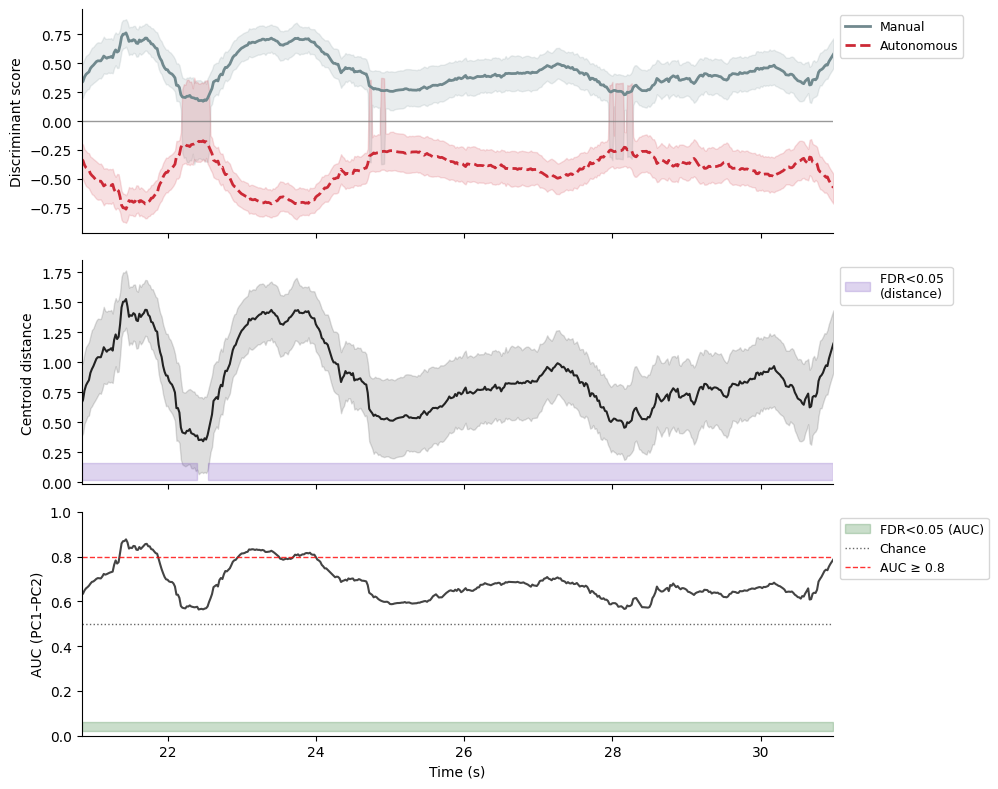

In [ ]:
# plot_timewise_panels(aligned_df, out_suffix="aligned", ylabel_prefix="")
plot_timewise_panels(
    results_df[results_df["Event"] == 'one'], 
    out_suffix="aligned", 
    save=True,
    ylabel_prefix="aligned"
    )

Saved: /Users/johnmadrid/GitHub/pca-driving-behavior/results/pc-interp/model_performance_aligned.png


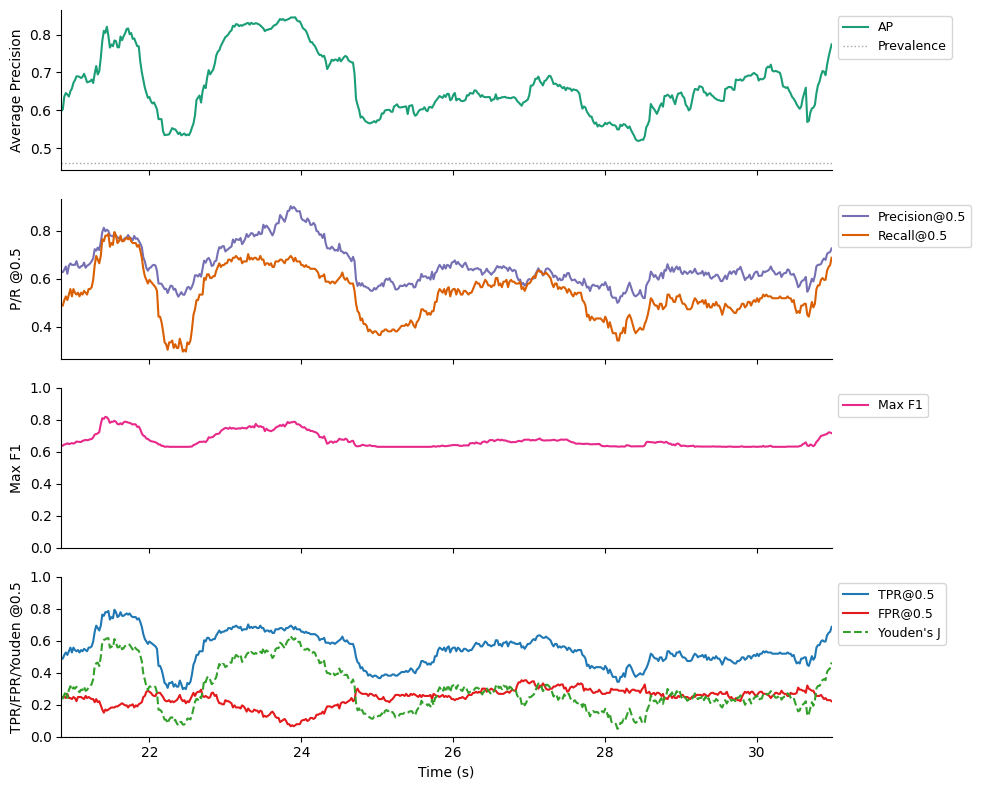

In [84]:
# After computing aligned_df above, call:
plot_model_performance(results_df[results_df["Event"] == 'one'], out_suffix="aligned")

## Results 
Load the results data to work with them instead of computing the model from start

In [9]:
out_df = pd.read_csv(OUTPUT_DIR / "timewise_discriminant_metrics_all_events.csv")
out_df.columns

Index(['Time', 'Manual_score_mean', 'Autonomous_score_mean', 'Manual_score_lo',
       'Manual_score_hi', 'Autonomous_score_lo', 'Autonomous_score_hi',
       'CentroidDistance', 'CentroidDistance_lo', 'CentroidDistance_hi', 'AUC',
       'p_auc', 'p_dist', 'auc_ge_thresh', 'AP', 'precision_0p5', 'recall_0p5',
       'f1_0p5', 'f1_max', 'thresh_f1_max', 'precision_f1_max',
       'recall_f1_max', 'prevalence', 'tpr_0p5', 'fpr_0p5', 'youden_j',
       'q_auc', 'q_dist', 'Event'],
      dtype='object')

Saved: /Users/johnmadrid/GitHub/pca-driving-behavior/results/pc-interp/timewise_discriminant_panels_aligned.pdf


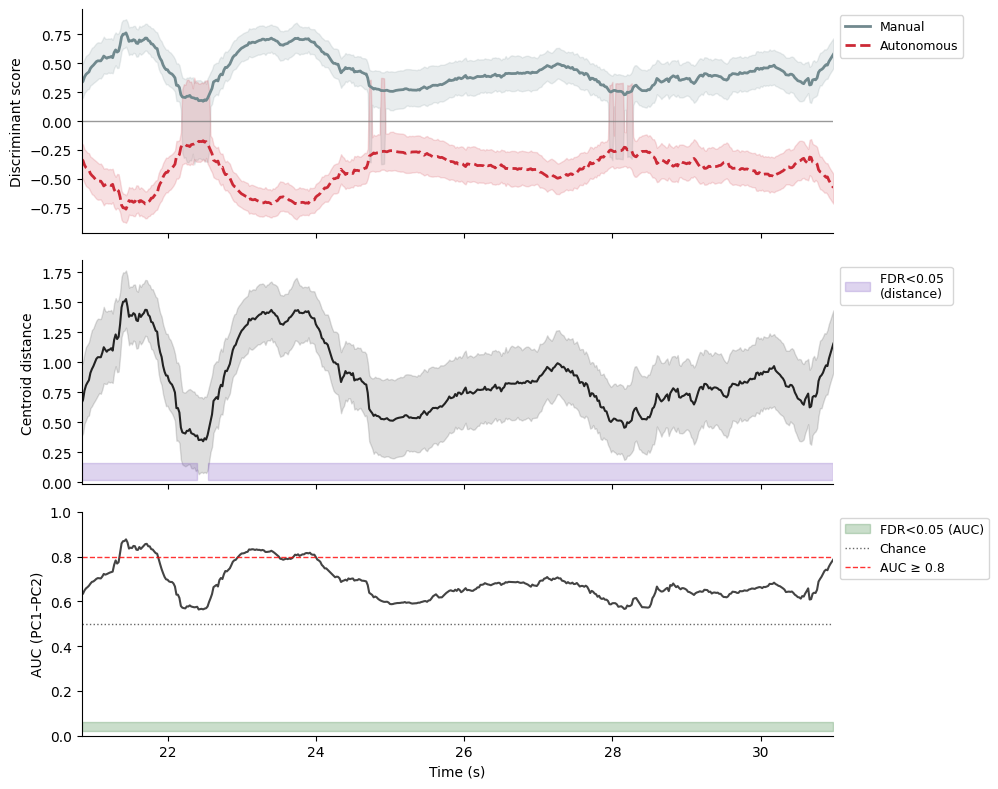

In [17]:
# plot_timewise_panels(aligned_df, out_suffix="aligned", ylabel_prefix="")
plot_timewise_panels(
    out_df[out_df["Event"] == 'one'], 
    out_suffix="aligned", 
    save=True,
    ylabel_prefix="aligned"
    )

## Summary statistics for AUC, Precision/Recall

In [10]:
# Create a summary table of discriminant metrics by 'Event'
# For example, compute mean and std for key metrics per Event
event_order = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

# Table 1: AUC and p_auc
auc_metrics = ["AUC"]
summary_auc_df = out_df.groupby("Event")[auc_metrics].agg(['max','mean', 'std']).reset_index()
summary_auc_df['Event'] = pd.Categorical(summary_auc_df['Event'], categories=event_order, ordered=True)
summary_auc_df = summary_auc_df.sort_values('Event').reset_index(drop=True)
# Display with two digits after the decimal point, center the AUC title, and hide the index
styled_auc = summary_auc_df.style.format(precision=2)
styled_auc = styled_auc.set_table_styles(
    [
        {'selector': 'th.col_heading', 'props': [('text-align', 'center')]},
        {'selector': 'th.col0', 'props': [('text-align', 'center')]},
        {'selector': 'th', 'props': [('text-align', 'center')]}
    ]
).hide(axis="index")
styled_auc

In [146]:
auc_metrics = ["AUC"]
pr_metrics = ["precision_0p5", "recall_0p5"]

# Compute mean AUC per event
mean_auc_per_event = out_df.groupby("Event")[auc_metrics].mean().reset_index()
# Compute mean precision and recall per event
mean_pr_per_event = out_df.groupby("Event")[pr_metrics].mean().reset_index()

# Compute the mean and std of the mean AUCs across events
mean_auc_across_events = mean_auc_per_event["AUC"].mean()
std_auc_across_events = mean_auc_per_event["AUC"].std()

# Compute the mean and std of the mean precision across events
mean_precision_across_events = mean_pr_per_event["precision_0p5"].mean()
std_precision_across_events = mean_pr_per_event["precision_0p5"].std()

# Compute the mean and std of the mean recall across events
mean_recall_across_events = mean_pr_per_event["recall_0p5"].mean()
std_recall_across_events = mean_pr_per_event["recall_0p5"].std()

print(f"The mean AUC per event is:\n{mean_auc_per_event}\n")
print(f"The mean precision per event is:\n{mean_pr_per_event[['Event', 'precision_0p5']]}\n")
print(f"The mean recall per event is:\n{mean_pr_per_event[['Event', 'recall_0p5']]}\n")

print(f"The mean of the mean AUCs across events is {mean_auc_across_events:.3f}, with a standard deviation of {std_auc_across_events:.3f}.")
print(f"The mean of the mean precision across events is {mean_precision_across_events:.3f}, with a standard deviation of {std_precision_across_events:.3f}.")
print(f"The mean of the mean recall across events is {mean_recall_across_events:.3f}, with a standard deviation of {std_recall_across_events:.3f}.")

The mean AUC per event is:
   Event       AUC
0  eight  0.648662
1   five  0.630440
2   four  0.674629
3   nine  0.688803
4    one  0.681415
5  seven  0.606558
6    six  0.783615
7    ten  0.641541
8  three  0.643697
9    two  0.750270

The mean precision per event is:
   Event  precision_0p5
0  eight       0.596528
1   five       0.594032
2   four       0.628497
3   nine       0.675122
4    one       0.650564
5  seven       0.606351
6    six       0.726716
7    ten       0.598972
8  three       0.620496
9    two       0.700008

The mean recall per event is:
   Event  recall_0p5
0  eight    0.478963
1   five    0.469940
2   four    0.527932
3   nine    0.496558
4    one    0.539370
5  seven    0.389909
6    six    0.664724
7    ten    0.507017
8  three    0.465669
9    two    0.615716

The mean of the mean AUCs across events is 0.675, with a standard deviation of 0.055.
The mean of the mean precision across events is 0.640, with a standard deviation of 0.047.
The mean of the mean recal

In [159]:
out_df.columns

Index(['Time', 'Manual_score_mean', 'Autonomous_score_mean', 'Manual_score_lo',
       'Manual_score_hi', 'Autonomous_score_lo', 'Autonomous_score_hi',
       'CentroidDistance', 'CentroidDistance_lo', 'CentroidDistance_hi', 'AUC',
       'p_auc', 'p_dist', 'auc_ge_thresh', 'AP', 'precision_0p5', 'recall_0p5',
       'f1_0p5', 'f1_max', 'thresh_f1_max', 'precision_f1_max',
       'recall_f1_max', 'prevalence', 'tpr_0p5', 'fpr_0p5', 'youden_j',
       'q_auc', 'q_dist', 'Event'],
      dtype='object')

In [245]:
event_order = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']
# Group by event, then calculate the mean and std for AUC, precision_0p5, and recall_0p5
event_grouped_stats = (
    out_df.groupby("Event")[["AUC", "precision_0p5", "recall_0p5"]]
    .agg(["mean", "std"])
    .reset_index()
)
# Ensure correct event order
event_grouped_stats["Event"] = pd.Categorical(event_grouped_stats["Event"], categories=event_order, ordered=True)
event_grouped_stats = event_grouped_stats.sort_values("Event").reset_index(drop=True)

print("Per-event mean and standard deviation for AUC, precision@0.5, and recall@0.5:")
print(event_grouped_stats)

# Compute the overall (across-event means) mean and std for those metrics
mean_auc_across_events = event_grouped_stats[("AUC", "mean")].mean()
std_auc_across_events = event_grouped_stats[("AUC", "mean")].std()

mean_precision_across_events = event_grouped_stats[("precision_0p5", "mean")].mean()
std_precision_across_events = event_grouped_stats[("precision_0p5", "mean")].std()

mean_recall_across_events = event_grouped_stats[("recall_0p5", "mean")].mean()
std_recall_across_events = event_grouped_stats[("recall_0p5", "mean")].std()

print(f"\nAcross events, mean of mean AUC = {mean_auc_across_events:.3f}, std = {std_auc_across_events:.3f}")
print(f"Across events, mean of mean precision@0.5 = {mean_precision_across_events:.3f}, std = {std_precision_across_events:.3f}")
print(f"Across events, mean of mean recall@0.5 = {mean_recall_across_events:.3f}, std = {std_recall_across_events:.3f}")

Per-event mean and standard deviation for AUC, precision@0.5, and recall@0.5:
   Event       AUC           precision_0p5           recall_0p5          
              mean       std          mean       std       mean       std
0    one  0.681415  0.076312      0.650564  0.084268   0.539370  0.106103
1    two  0.750270  0.141061      0.700008  0.142733   0.615716  0.192693
2  three  0.643697  0.101155      0.620496  0.116666   0.465669  0.162069
3   four  0.674629  0.086053      0.628497  0.089715   0.527932  0.124770
4   five  0.630440  0.048816      0.594032  0.056842   0.469940  0.088146
5    six  0.783615  0.073731      0.726716  0.067907   0.664724  0.088678
6  seven  0.606558  0.062082      0.606351  0.088520   0.389909  0.095223
7  eight  0.648662  0.076867      0.596528  0.089474   0.478963  0.156498
8   nine  0.688803  0.110000      0.675122  0.110191   0.496558  0.168642
9    ten  0.641541  0.058116      0.598972  0.054369   0.507017  0.086480

Across events, mean of mean AUC =

In [248]:
event_order = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

# Group by event and find the row (timepoint) with the maximum AUC for each event
# Then extract Event, the max AUC, its Time, precision and recall at that timepoint
max_auc_by_event = (
    out_df.loc[out_df.groupby("Event")["AUC"].idxmax()]
    .reset_index(drop=True)
    .loc[:, ["Event", "Time", "AUC", "precision_0p5", "recall_0p5"]]
)

# Ensure correct event order
max_auc_by_event["Event"] = pd.Categorical(max_auc_by_event["Event"], categories=event_order, ordered=True)
max_auc_by_event = max_auc_by_event.sort_values("Event").reset_index(drop=True)

print("Per-event maximum AUC and corresponding Time, precision@0.5, and recall@0.5:")
print(max_auc_by_event)

# Calculate mean and std for max AUC, precision, and recall across events
mean_max_auc = max_auc_by_event["AUC"].mean()
std_max_auc = max_auc_by_event["AUC"].std()
mean_precision_at_max_auc = max_auc_by_event["precision_0p5"].mean()
std_precision_at_max_auc = max_auc_by_event["precision_0p5"].std()
mean_recall_at_max_auc = max_auc_by_event["recall_0p5"].mean()
std_recall_at_max_auc = max_auc_by_event["recall_0p5"].std()

print(f"\nThe mean of the maximum AUCs across events is {mean_max_auc:.3f}, with a standard deviation of {std_max_auc:.3f}.")
print(f"The mean precision at max AUC across events is {mean_precision_at_max_auc:.3f}, with a standard deviation of {std_precision_at_max_auc:.3f}.")
print(f"The mean recall at max AUC across events is {mean_recall_at_max_auc:.3f}, with a standard deviation of {std_recall_at_max_auc:.3f}.")

Per-event maximum AUC and corresponding Time, precision@0.5, and recall@0.5:
   Event    Time       AUC  precision_0p5  recall_0p5
0    one   21.44  0.876466       0.803150    0.778626
1    two   69.98  0.986130       0.976378    0.946565
2  three  135.12  0.909395       0.872881    0.786260
3   four  192.38  0.865689       0.835938    0.816794
4   five  231.80  0.814299       0.801802    0.679389
5    six  275.48  0.947613       0.890625    0.870229
6  seven  340.86  0.754777       0.740385    0.587786
7  eight  397.30  0.824727       0.768000    0.732824
8   nine  436.12  0.911440       0.868852    0.809160
9    ten  469.28  0.811571       0.678571    0.725191

The mean of the maximum AUCs across events is 0.870, with a standard deviation of 0.070.
The mean precision at max AUC across events is 0.824, with a standard deviation of 0.085.
The mean recall at max AUC across events is 0.773, with a standard deviation of 0.100.


In [250]:
# Across-event summaries for discriminant scores, centroid distance, and AUC/PR

# Load combined results if not already loaded in this session
try:
    out_df
except NameError:
    out_df = pd.read_csv(OUTPUT_DIR / "timewise_discriminant_metrics_all_events.csv")

from typing import Dict, Tuple

def bootstrap_ci(values: np.ndarray, reps: int = 10000, seed: int = RANDOM_STATE) -> Tuple[float, float]:
    vals = np.asarray(values, dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return (np.nan, np.nan)
    if vals.size == 1:
        v = float(vals[0])
        return (v, v)
    rng = np.random.default_rng(seed)
    samples = rng.choice(vals, size=(reps, vals.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(samples, [2.5, 97.5])
    return float(lo), float(hi)

def summarize_across_events(series: pd.Series) -> Dict[str, float]:
    vals = series.to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return {"mean": np.nan, "sd": np.nan, "ci_lo": np.nan, "ci_hi": np.nan, "n_events": 0}
    mean = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0
    ci_lo, ci_hi = bootstrap_ci(vals)
    return {"mean": mean, "sd": sd, "ci_lo": ci_lo, "ci_hi": ci_hi, "n_events": int(vals.size)}

# Per-time discriminant difference, then average its magnitude per event (to match centroid distance expectation)
out_df = out_df.copy()
out_df["disc_diff"] = out_df["Manual_score_mean"] - out_df["Autonomous_score_mean"]

# Per-event means across time (for appendix/table), then summarize across events
per_event = out_df.groupby("Event").agg({
    "Manual_score_mean": "mean",
    "Autonomous_score_mean": "mean",
    "CentroidDistance": "mean",
    "disc_diff": lambda x: float(np.mean(np.abs(x))),  # mean |Manual − Autonomous|
    "AUC": "mean",
    "precision_0p5": "mean",
    "recall_0p5": "mean",
    "f1_0p5": "mean",
    "f1_max": "mean",
}).reset_index()

# Per-event average magnitudes of group means across time
mag_df = out_df.groupby("Event").agg(
    Manual_mag=("Manual_score_mean", lambda x: float(np.mean(np.abs(x)))),
    Auto_mag=("Autonomous_score_mean", lambda x: float(np.mean(np.abs(x))))
).reset_index()
per_event = per_event.merge(mag_df, on="Event", how="left")

# Calculation: Signed discriminant difference (Manual − Autonomous) using per-time magnitude average
per_event.rename(columns={"disc_diff": "Disc_diff_abs_mean"}, inplace=True)

# Orient group means per event so Manual is positive and Autonomous negative
event_sign = out_df.groupby("Event")["disc_diff"].mean().apply(lambda x: 1.0 if x >= 0 else -1.0)
per_event = per_event.merge(event_sign.rename("event_sign"), on="Event", how="left")
per_event["Manual_score_mean_oriented"] = per_event["Manual_score_mean"] * per_event["event_sign"]
per_event["Autonomous_score_mean_oriented"] = per_event["Autonomous_score_mean"] * per_event["event_sign"]

# Add to summary: also include |Disc_diff_signed| (magnitude) as "abs_disc_diff"
summary: Dict[str, Dict[str, float]] = {
    # Report average magnitudes (so Manual + Autonomous ≈ |Manual − Autonomous| when means are symmetric)
    "manual_disc": summarize_across_events(per_event["Manual_mag"]),
    "auto_disc": summarize_across_events(-per_event["Auto_mag"]), # make Autonomous negative for consistency
    "disc_diff_abs_mean": summarize_across_events(per_event["Disc_diff_abs_mean"]),
    "centroid_distance": summarize_across_events(per_event["CentroidDistance"]),
    "auc_mean": summarize_across_events(per_event["AUC"]),
    "precision_mean_0p5": summarize_across_events(per_event["precision_0p5"]),
    "recall_mean_0p5": summarize_across_events(per_event["recall_0p5"]),
    "f1_mean_0p5": summarize_across_events(per_event["f1_0p5"]),
    "f1_mean_max": summarize_across_events(per_event["f1_max"]),
}

# Max AUC per event and corresponding P/R at that time
idx = out_df.groupby("Event")["AUC"].idxmax()
max_rows = out_df.loc[idx, ["Event", "AUC", "precision_0p5", "recall_0p5", "f1_0p5", "f1_max"]].reset_index(drop=True)

summary.update({
    "auc_at_max": summarize_across_events(max_rows["AUC"]),
    "precision_at_max_0p5": summarize_across_events(max_rows["precision_0p5"]),
    "recall_at_max_0p5": summarize_across_events(max_rows["recall_0p5"]),
    "f1_at_max_0p5": summarize_across_events(max_rows["f1_0p5"]),
    "f1_at_max_max": summarize_across_events(max_rows["f1_max"]),
})
  
# Nicely formatted summary table for quick reference

def _as_table(label: str, stats: Dict[str, float]) -> Dict[str, float]:
    return {
        "metric": label,
        "mean": stats["mean"],
        "sd": stats["sd"],
        "ci_lo": stats["ci_lo"],
        "ci_hi": stats["ci_hi"],
        "n_events": stats["n_events"],
    }

summary_table = pd.DataFrame([
    _as_table("Manual disc. score (event means → across-event)", summary["manual_disc"]),
    _as_table("Autonomous disc. score (event means → across-event)", summary["auto_disc"]),
    _as_table("|Manual − Autonomous| disc. difference (per-time avg → per-event)", summary["disc_diff_abs_mean"]),
    _as_table("Centroid distance (event means → across-event)", summary["centroid_distance"]),
    _as_table("AUC (event means → across-event)", summary["auc_mean"]),
    _as_table("Precision@0.5 (event means → across-event)", summary["precision_mean_0p5"]),
    _as_table("Recall@0.5 (event means → across-event)", summary["recall_mean_0p5"]),
    _as_table("F1@0.5 (event means → across-event)", summary["f1_mean_0p5"]),
    _as_table("Max F1 (event means → across-event)", summary["f1_mean_max"]),
    _as_table("AUC at max per event (across-event)", summary["auc_at_max"]),
    _as_table("Precision@0.5 at max AUC (across-event)", summary["precision_at_max_0p5"]),
    _as_table("Recall@0.5 at max AUC (across-event)", summary["recall_at_max_0p5"]),
    _as_table("F1@0.5 at max AUC (across-event)", summary["f1_at_max_0p5"]),
    _as_table("Max F1 at max AUC (across-event)", summary["f1_at_max_max"]),
])

print("Across-event summary (mean ± SD, 95% bootstrap CI across events):")
try:
    from IPython.display import display
    display(summary_table)
except Exception:
    print(summary_table.to_string(index=False))

# Expose a few convenient variables for manuscript text if desired
MANUAL_DISC = summary["manual_disc"]
AUTO_DISC = summary["auto_disc"]
# DISC_DIFF_SIGNED = summary["disc_diff_signed"]
# ABS_DISC_DIFF = summary["abs_disc_diff"]
DIST = summary["centroid_distance"]
AUC_MEAN = summary["auc_mean"]
P_MEAN = summary["precision_mean_0p5"]
R_MEAN = summary["recall_mean_0p5"]
AUC_AT_MAX = summary["auc_at_max"]
P_AT_MAX = summary["precision_at_max_0p5"]
R_AT_MAX = summary["recall_at_max_0p5"]

Across-event summary (mean ± SD, 95% bootstrap CI across events):


,metric,mean,sd,ci_lo,ci_hi,n_events
0,Manual disc. score (event means → across-event),0.399559,0.103550,0.343541,0.464556,10
1,Autonomous disc. score (event means → across-e...,-0.399559,0.103550,-0.464556,-0.343541,10
2,|Manual − Autonomous| disc. difference (per-ti...,0.799118,0.207101,0.687082,0.929112,10
3,Centroid distance (event means → across-event),0.799118,0.207101,0.687082,0.929112,10
4,AUC (event means → across-event),0.674963,0.054932,0.645317,0.709138,10
5,Precision@0.5 (event means → across-event),0.639729,0.046900,0.613906,0.668347,10
6,Recall@0.5 (event means → across-event),0.515580,0.078268,0.472131,0.563741,10
7,F1@0.5 (event means → across-event),0.566382,0.065592,0.530661,0.607370,10
8,Max F1 (event means → across-event),0.678967,0.031530,0.661969,0.698677,10
9,AUC at max per event (across-event),0.870211,0.070460,0.829640,0.911740,10


In [ ]:
out_df[out_df['Event']=='one'][[
    'Manual_score_mean','Manual_score_lo','Manual_score_hi',
    'Autonomous_score_mean','Autonomous_score_lo','Autonomous_score_hi'
]].agg(['mean', 'std']).T


,mean,std
Manual_score_mean,0.431440,0.140861
Manual_score_lo,0.261603,0.216697
Manual_score_hi,0.577124,0.128283
Autonomous_score_mean,-0.431440,0.140861
Autonomous_score_lo,-0.577124,0.128283
Autonomous_score_hi,-0.261603,0.216697


Average centroid distance for event one.

In [226]:
# Summarize discriminant score: mean ± SD; 95% CI
_DISC = out_df[out_df['Event']=='one']['CentroidDistance']
_DISC_lo = out_df[out_df['Event']=='one']['CentroidDistance_lo']
_DISC_hi = out_df[out_df['Event']=='one']['CentroidDistance_hi']

disc_mean = _DISC.mean()
disc_sd = _DISC.std()
ci_lo = _DISC_lo.mean() if not _DISC_lo.isnull().all() else float('nan')
ci_hi = _DISC_hi.mean() if not _DISC_hi.isnull().all() else float('nan')

print(f"CentroidDistance (one): {disc_mean:.5f} ± {disc_sd:.5f}; 95% CI: {ci_lo:.5f}–{ci_hi:.5f}")

CentroidDistance (one): 0.86288 ± 0.28172; 95% CI: 0.58465–1.15530


In [227]:
# Mean and std of Manual, Autonomous discriminant scores, and Centroid distance, across events
# Manual scores always positive, Autonomous always negative

event_order = ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']

event_stats = (
    out_df.groupby(['Event'])[
        ['Manual_score_mean', 'Autonomous_score_mean', 'CentroidDistance']
    ]
    .agg(['mean', 'std'])
    .reindex(event_order, level='Event', axis=0)
)

# Update: make manual scores always positive, autonomous always negative
event_stats[('Manual_score_mean', 'mean')] = event_stats[('Manual_score_mean', 'mean')].abs()
event_stats[('Autonomous_score_mean', 'mean')] = -event_stats[('Autonomous_score_mean', 'mean')].abs()
# CentroidDistance stays as is, since it's typically positive

print(event_stats)

# Print the overall mean and std (across all events)
overall_manual = event_stats[('Manual_score_mean', 'mean')].abs()
overall_auto = -event_stats[('Autonomous_score_mean', 'mean')].abs()
overall_centroid = event_stats[('CentroidDistance', 'mean')]

overall_stats = pd.DataFrame({
    'Manual_score_mean': [overall_manual.mean(), overall_manual.std()],
    'Autonomous_score_mean': [overall_auto.mean(), overall_auto.std()],
    'CentroidDistance': [overall_centroid.mean(), overall_centroid.std()],
}, index=['mean', 'std'])

print("\nOverall mean and std across all events:")
print(overall_stats)

      Manual_score_mean           Autonomous_score_mean            \
                   mean       std                  mean       std   
Event                                                               
one            0.431440  0.140861             -0.431440  0.140861   
two            0.518743  0.306702             -0.518743  0.306702   
three          0.349970  0.183907             -0.349970  0.183907   
four           0.407535  0.134169             -0.407535  0.134169   
five           0.297264  0.123777             -0.297264  0.123777   
six            0.602341  0.142468             -0.602341  0.142468   
seven          0.020561  0.290591             -0.020561  0.290591   
eight          0.171209  0.303489             -0.171209  0.303489   
nine           0.346719  0.291284             -0.346719  0.291284   
ten            0.351273  0.095714             -0.351273  0.095714   

      CentroidDistance            
                  mean       std  
Event                           

In [ ]:
# Within-event time-averaged summary (block bootstrap) — runs only if a single event is present
out_df1 = out_df#[out_df['Event']=='one']
if out_df1["Event"].nunique() > 1:
    ev_name = str(out_df1["Event"].iloc[0])

    # def block_bootstrap_ci_time(values: np.ndarray, block_len: int | None = None, reps: int = 10000,
    #                              seed: int = RANDOM_STATE) -> tuple[float, float]:
    #     v = np.asarray(values, dtype=float)
    #     v = v[~np.isnan(v)]
    #     n = v.size
    #     if n == 0:
    #         return (np.nan, np.nan)
    #     if n == 1:
    #         m = float(v[0])
    #         return (m, m)
    #     if block_len is None:
    #         block_len = max(5, int(np.sqrt(n)))  # rule-of-thumb
    #     rng = np.random.default_rng(seed)
    #     means = np.empty(reps, dtype=float)
    #     for i in range(reps):
    #         idx = []
    #         while len(idx) < n:
    #             start = int(rng.integers(0, n))
    #             stop = min(start + block_len, n)
    #             idx.extend(range(start, stop))
    #         sample = v[np.array(idx[:n])]
    #         means[i] = float(np.mean(sample))
    #     lo, hi = np.percentile(means, [2.5, 97.5])
    #     return float(lo), float(hi)

    def summarize_time_series(series: pd.Series) -> dict:
        vals = series.to_numpy(dtype=float)
        vals = vals[~np.isnan(vals)]
        n = vals.size
        if n == 0:
            return {"mean": np.nan, "sd": np.nan, "ci_lo": np.nan, "ci_hi": np.nan}
        mean = float(np.mean(vals))
        if n == 1:
            sd = 0.0
            ci_lo = mean
            ci_hi = mean
        else:
            sd = float(np.std(vals, ddof=1))
            se = sd / np.sqrt(n)
            ci_lo = float(mean - 1.96 * se)
            ci_hi = float(mean + 1.96 * se)
        return {"mean": mean, "sd": sd, "ci_lo": ci_lo, "ci_hi": ci_hi}

    ev_df = out_df1.copy()
    # Discriminant differences across time (Manual − Autonomous)
    disc_diff_signed = ev_df["Manual_score_mean"] - ev_df["Autonomous_score_mean"]
    disc_diff_abs = disc_diff_signed.abs()

    within = {
        "manual_disc": summarize_time_series(ev_df["Manual_score_mean"]),
        "auto_disc": summarize_time_series(ev_df["Autonomous_score_mean"]),
        "disc_diff_signed": summarize_time_series(disc_diff_signed),
        "disc_diff_abs": summarize_time_series(disc_diff_abs),
        "centroid_distance": summarize_time_series(ev_df["CentroidDistance"]),
        "auc_mean": summarize_time_series(ev_df["AUC"]),
        "precision_mean_0p5": summarize_time_series(ev_df["precision_0p5"]),
        "recall_mean_0p5": summarize_time_series(ev_df["recall_0p5"]),
        "f1_mean_0p5": summarize_time_series(ev_df["f1_0p5"]),
        "f1_mean_max": summarize_time_series(ev_df["f1_max"]),
    }

    def _row(label: str, stats: dict) -> dict:
        return {
            "metric": label,
            "mean": stats["mean"],
            "sd": stats["sd"],
            "ci_lo": stats["ci_lo"],
            "ci_hi": stats["ci_hi"],
        }

    within_table = pd.DataFrame([
        _row("Manual discriminant score (across-time)", within["manual_disc"]),
        _row("Autonomous discriminant score (across-time)", within["auto_disc"]),
        _row("Discriminant difference Manual−Autonomous (signed, across-time)", within["disc_diff_signed"]),
        _row("|Discriminant difference| (across-time)", within["disc_diff_abs"]),
        _row("Centroid distance (across-time)", within["centroid_distance"]),
        _row("AUC (across-time)", within["auc_mean"]),
        _row("Precision@0.5 (across-time)", within["precision_mean_0p5"]),
        _row("Recall@0.5 (across-time)", within["recall_mean_0p5"]),
        _row("F1@0.5 (across-time)", within["f1_mean_0p5"]),
        _row("Max F1 (across-time)", within["f1_mean_max"]),
    ])

    print(f"Within-event time-averaged summary for event '{ev_name}' (mean ± SD across time, 95% block-bootstrap CI; block_len≈√n):")
    try:
        from IPython.display import display
        display(within_table)
    except Exception:
        print(within_table.to_string(index=False))



Within-event time-averaged summary for event 'eight' (mean ± SD across time, 95% block-bootstrap CI; block_len≈√n):


,metric,mean,sd,ci_lo,ci_hi
0,Manual discriminant score (across-time),0.075441,0.430999,0.065738,0.085145
1,Autonomous discriminant score (across-time),-0.075441,0.430999,-0.085145,-0.065738
2,Discriminant difference Manual−Autonomous (sig...,0.150882,0.861998,0.131475,0.170289
3,|Discriminant difference| (across-time),0.786256,0.384096,0.777608,0.794903
4,Centroid distance (across-time),0.786256,0.384096,0.777608,0.794903
5,AUC (across-time),0.672562,0.105065,0.670196,0.674927
6,Precision@0.5 (across-time),0.639030,0.107984,0.636599,0.641461
7,Recall@0.5 (across-time),0.507975,0.159037,0.504394,0.511555
8,F1@0.5 (across-time),0.560788,0.141211,0.557609,0.563968
9,Max F1 (across-time),0.679056,0.062146,0.677657,0.680455


### Step-by-step data flow and AUC computation (diagnostics)
This cell prints, for selected timestamps, the exact data objects used at each stage:
- input behavioral matrix `X` (participants × 7), labels `y`
- standardized data, PCA scores/loadings
- aligned scores/loadings
- discriminant axis and scalar projections
- stratified K-fold splits and held-out probabilities for AUC



In [151]:
from pprint import pprint

# Pick times to debug
if not DEBUG_TIMES and len(unique_times) > 0:
    DEBUG_TIMES = [unique_times[0]]

printed = 0
for t in DEBUG_TIMES:
    if printed >= MAX_DEBUG_PRINTS:
        break
    dft = df[df[TIME_COL] == t].copy()
    X = dft[FEATURES].to_numpy(dtype=float)
    y = dft[COND_COL].to_numpy(dtype=int)

    print("\n=== DEBUG for Time:", t, "===")
    print("Raw input X shape:", X.shape, "(participants × 7)")
    print("First 2 rows of X:")
    print(np.round(X[:2, :], 3))
    print("Labels y shape:", y.shape, "values (first 10):", y[:10])

    # Standardize + PCA
    scores_raw, pca, scaler = _compute_pca_scores(X, n_components=2)
    Xs = scaler.transform(X)
    loadings = pca.components_.T

    print("Standardized Xs mean (approx 0):", np.round(Xs.mean(axis=0), 3))
    print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4), "| sum=", round(float(np.sum(pca.explained_variance_ratio_)), 4))
    print("Scores_raw shape:", scores_raw.shape, "(participants × 2)")
    print("Check: Xs @ loadings ≈ scores_raw? max|diff|=", float(np.max(np.abs(Xs @ loadings - scores_raw))))
    print("First 2 PC scores (raw):")
    print(np.round(scores_raw[:2, :], 3))
    print("Loadings shape:", loadings.shape, "(7 × 2). Rows follow FEATURES order:")
    for f, row in zip(FEATURES, np.round(loadings, 3)):
        print(f"  {f:>15}: {row}")

    # Alignment (here we use a trivial reference -> R may be identity on the first time)
    aligned_loadings, R = _align_basis(loadings, ref_loadings=None, prev_loadings=None)
    scores = scores_raw @ R
    ortho_err = float(np.linalg.norm(R.T @ R - np.eye(2)))
    detR = float(np.linalg.det(R))
    angle = float(np.degrees(np.arctan2(R[1, 0], R[0, 0])))
    print("Alignment R (2×2):\n", np.round(R, 4), "| orthogonality error=", round(ortho_err, 6), ", det(R)=", round(detR, 6), ", angle(deg)=", round(angle, 2))
    print("Aligned scores (first 2):\n", np.round(scores[:2, :], 3))

    # Show that alignment is a pure rotation in the PC plane (norms preserved)
    pre_norms = np.linalg.norm(scores_raw[:5, :], axis=1)
    post_norms = np.linalg.norm(scores[:5, :], axis=1)
    print("First 5 norms (raw vs aligned):")
    print("  raw:", np.round(pre_norms, 3))
    print("  alg:", np.round(post_norms, 3))

    # Discriminant
    v, m, s, s0, s1, dist = _compute_discriminant(scores, y, prev_v=None)
    print("Discriminant axis v:", np.round(v, 3))
    # Double check: label 1 = Manual, label 0 = Autonomous
    print("Centroids (Autonomous [label 0], Manual [label 1]) in aligned PC space:")
    c0 = scores[y == 0].mean(axis=0)  # Autonomous
    c1 = scores[y == 1].mean(axis=0)  # Manual
    print("  Autonomous (label 0):", np.round(c0, 3), " Manual (label 1):", np.round(c1, 3))
    print("Centroid distance:", round(dist, 3))
    print("Group means along v (Autonomous [label 0], Manual [label 1]):", round(s0, 3), round(s1, 3))

    # Stratified K-fold AUC, with explicit splits printed
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, CV_FOLDS))
    # Double check: class_counts[0] = Autonomous, class_counts[1] = Manual
    print("Class counts [Autonomous (label 0), Manual (label 1)]:", class_counts.tolist(), "| folds:", max_folds)
    from sklearn.model_selection import StratifiedKFold
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score

    # Save classifier input data for inspection
    classifier_input_df = None

    if max_folds >= 2:
        skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
        prob_all = np.zeros(len(y))
        fold_data = []
        for k, (tr, te) in enumerate(skf.split(scores, y), start=1):
            clf = LogisticRegression(C=10.0, solver="lbfgs")
            clf.fit(scores[tr], y[tr])
            prob = clf.predict_proba(scores[te])[:, 1]
            prob_all[te] = prob
            print(f"  Fold {k}: train={len(tr)} (shape {scores[tr].shape}), test={len(te)} (shape {scores[te].shape}) | prob[0:2]", np.round(prob[:2], 3))
            # Save the data for this fold
            fold_df = {
                'fold': k,
                'train_scores': scores[tr],
                'train_labels': y[tr],
                'test_scores': scores[te],
                'test_labels': y[te],
                'test_prob': prob
            }
            fold_data.append(fold_df)
        # Save all fold data into a DataFrame for inspection
        import pandas as pd
        classifier_input_df = pd.DataFrame({
            'fold': [fd['fold'] for fd in fold_data],
            'train_scores': [fd['train_scores'] for fd in fold_data],
            'train_labels': [fd['train_labels'] for fd in fold_data],
            'test_scores': [fd['test_scores'] for fd in fold_data],
            'test_labels': [fd['test_labels'] for fd in fold_data],
            'test_prob': [fd['test_prob'] for fd in fold_data]
        })
        print("Saved classifier input data for all folds to 'classifier_input_df' (shape:", classifier_input_df.shape, ")")
        auc = roc_auc_score(y, prob_all)
        print("AUC (out-of-fold):", round(auc, 3))
    else:
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        prob = clf.predict_proba(scores)[:, 1]
        auc = roc_auc_score(y, prob)
        # Save the single in-sample classifier input
        import pandas as pd
        classifier_input_df = pd.DataFrame({
            'scores': [scores],
            'labels': [y],
            'prob': [prob]
        })
        print("Saved classifier input data for in-sample fit to 'classifier_input_df' (shape:", classifier_input_df.shape, ")")
        print("AUC (in-sample; low-N fallback):", round(auc, 3))

    printed += 1



=== DEBUG for Time: 0.0 ===
Raw input X shape: (284, 7) (participants × 7)
First 2 rows of X:
[[ -1.612  -3.785  74.761   3.1     0.211   5.025  -0.218]
 [  4.641 -18.482  74.87    0.181  -0.221  -3.51   -0.218]]
Labels y shape: (284,) values (first 10): [0 0 0 0 0 0 0 0 0 0]
Standardized Xs mean (approx 0): [ 0.  0.  0. -0. -0. -0. -0.]
Explained variance ratio (PC1, PC2): [0.2452 0.1857] | sum= 0.4309
Scores_raw shape: (284, 2) (participants × 2)
Check: Xs @ loadings ≈ scores_raw? max|diff|= 5.10702591327572e-15
First 2 PC scores (raw):
[[ 0.587  0.365]
 [ 0.822 -0.253]]
Loadings shape: (7, 2) (7 × 2). Rows follow FEATURES order:
   Eye Horizontal: [-0.033 -0.56 ]
     Eye Vertical: [-0.562 -0.052]
          Car Yaw: [-0.01   0.563]
         Head Yaw: [-0.035  0.295]
       Head Pitch: [-0.498  0.08 ]
        Head Roll: [0.656 0.055]
         Steering: [ 0.052 -0.52 ]
Alignment R (2×2):
 [[1. 0.]
 [0. 1.]] | orthogonality error= 0.0 , det(R)= 1.0 , angle(deg)= 0.0
Aligned scores (fi

In [27]:
classifier_input_df['test_labels'][0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [22]:
len(y)

284